# Hospital Saturation Decision Framework
### Scoring System on Catanduanes' Hospitals

Located in **Region V-Bicol**, Catanduanes is an island province with a total population of roughly **261,000**. 6 Hospitals are designated to accommodate the whole island. This project entails what's the most probable decision to take as this scores which municipalities and hospitals suffer in coming years.

## **IMPORT LIBRARIES**
---

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

## **DATA GATHERING**
---
* Population figures used are from the PSA's 2024 census Catanduanes' municipalities wherein  [11 Municipalities](https://rsso05.psa.gov.ph/content/highlights-2024-census-population-virac) was listed.
    * *Extraction Method:* Automated via Gemini Multimodal Vision (OCR).
* Procured [Validated Hospitals](https://hfsrb.doh.gov.ph/list-of-licensed-health-facilities/) as of December 31, 2025
    *  I then *filtered* for the hospitals that is located on the island.
* [Mortality Death Rate](https://rsso05.psa.gov.ph/content/catanduanes-preliminary-death-statistics-2025?__cf_chl_tk=Jn5doLCk5ZNHrEv35acRu7IpN17hlvRefosHVzL00y0-1776930243-1.0.1.1-UzXKXAaVKlA83J8ylQP1mYl6.LRmgywQyBDF560iF3g) was gathered from PSA Catanduanes
* Used Google Maps to simulate travel times between municipalities and its nearest hospitals

## **TECH STACK**
---

| Layer | Technology | Role & Purpose |
| :--- | :--- | :--- |
| **Infrastructure** | **Docker** | PostgreSQL Containerization & Environment Isolation |
| **Database** | **PostgreSQL** | Centralized storage for Census and Hospital datasets |
| **Management** | **DBeaver** | SQL Client for data inspection and schema design |
| **IDE** | **AntiGravity** | Core development and logic implementation |
| **Analytics** | **Jupyter Notebook** | Interactive analysis, 2SFCA scoring, and visualization |
| **Knowledge Base** | **Obsidian** | Framework documentation and project second-brain |
| **Language** | **Python 3.12** | Data processing via **Pandas** and **GeoPandas** |

## **HOSPITAL DATA**

Most of the hospitals are located in Virac which is the capital municipality of the island and also where most of the population reside. 4 of them are government owned to provide better accessibility for the general population. To align with the Department of Health’s (DOH) strategic goals for the [Universal Health Care](https://www.washinhcf.org/wp-content/uploads/2025/04/DOH_PHILIPPINE-HEALTH-FACILITY-DEVELOPMENT-PLAN-2020_2040.pdf) (UHC) Act, hospital accessibility should ideally be optimized toward a **30-minute travel** threshold to ensure timely primary and emergency intervention. In this study, we will find out which municipalities are in 

---

In [2]:
hsp = pd.read_csv('Downloads/catnes_hsp.csv')

hsp = hsp[['hospital_name', 'municipality', 'ownership', 'beds']]
hsp['beds'] = pd.to_numeric(hsp['beds'], errors='coerce')
hsp_summary = hsp.groupby(['hospital_name', 'municipality', 'ownership'])['beds'].sum().reset_index()

# This line shifts the index to start from 1
hsp_summary.index = hsp_summary.index + 1

hsp_summary.style \
    .set_properties(**{'text-align': 'left'}) \
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}])

,hospital_name,municipality,ownership,beds
1,"CATANDUANES DOCTORS HOSPITAL, INC.",Virac,Private,60
2,EASTERN BICOL MEDICAL CENTER,Virac,Government,84
3,"IMMACULATE HEART OF MARY HOSPITAL, INC.",Virac,Private,36
4,JUAN M. ALBERTO MEMORIAL DISTRICT HOSPITAL,San Andres,Government,25
5,PANDAN DISTRICT HOSPITAL,Pandan,Government,25
6,VIGA DISTRICT HOSPITAL,Viga,Government,25


## **MORTALITY DATA** (top causes)

A significant proportion of deaths lack a recorded underlying cause, which may reflect limitations in medical certification, access to diagnostic services, or reporting practices. **Cardiovascular** is the most prominent category in terms of causes of death in the island which can be mitigated by having hospitals just minutes away from the emergency.

---

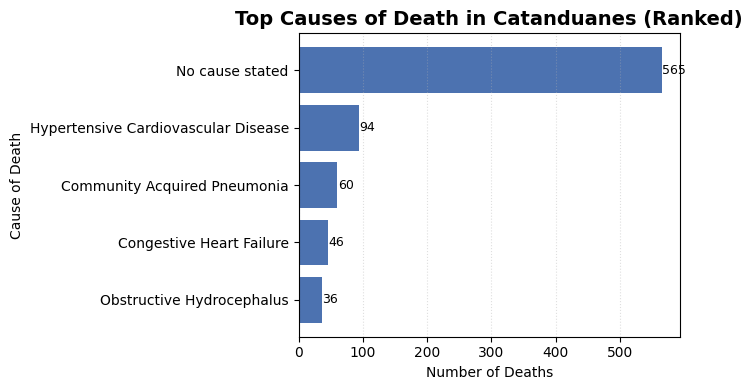

In [3]:
mrt_summary = pd.read_csv("Downloads/mort2.csv")
plot_data = mrt_summary.head(10).copy()
plot_data = plot_data.sort_values(by='death_count', ascending=True)
plt.figure(figsize=(7,4))

bars = plt.barh(
    plot_data['cause_detail'],
    plot_data['death_count'],
    color='#4C72B0'
)
plt.title('Top Causes of Death in Catanduanes (Ranked)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Deaths')
plt.ylabel('Cause of Death')
for bar in bars:
    plt.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height()/2,
        f'{int(bar.get_width())}',
        va='center',
        fontsize=9
    )
plt.grid(axis='x', linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

## **HOSPITAL ACCESSIBILITY**

The accessibility table identifies a significant compliance gap, **Caramoran** (51min), **Gigmoto** (1hr 18min) and **Baras** (1hr 4min) are statistically "underserved".

---


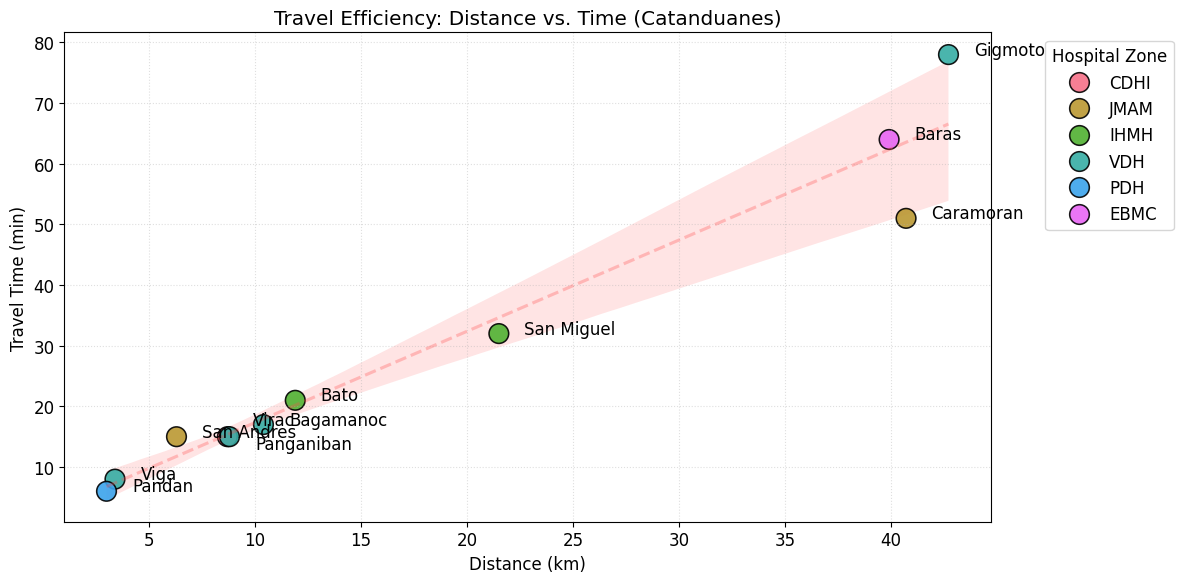

In [4]:
plt.rcParams.update({'font.size': 12})
df = pd.read_csv("Downloads/accessibility.csv")
plt.figure(figsize=(12, 6))
sns.regplot(data=df, x="Distance_km", y="TravelTime_min", 
            scatter=False, line_kws={"color":"#FF4B4B", "alpha":0.3, "linestyle":"--"})
sns.scatterplot(data=df, x="Distance_km", y="TravelTime_min", 
                hue="Nearest_Hospital", s=200, palette="husl", edgecolor="black", alpha=0.9)

for i in range(len(df)):
    x = df["Distance_km"].iloc[i]
    y = df["TravelTime_min"].iloc[i]
    name = df["Municipality"].iloc[i]
    
    if name == "Virac":
        plt.text(x + 1.2, y + 2, name)
    elif name == "Panganiban":
        plt.text(x + 1.2, y - 2, name)
    else:
        plt.text(x + 1.2, y, name)

plt.title("Travel Efficiency: Distance vs. Time (Catanduanes)")
plt.xlabel("Distance (km)")
plt.ylabel("Travel Time (min)")
plt.grid(True, linestyle=":", alpha=0.4)
plt.legend(title="Hospital Zone", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show();

## **HOSPITAL SATURATION**

List of hospitals in Catanduanes and the total population they serve, calculated by adding up the residents of the towns closest to each facility.

---

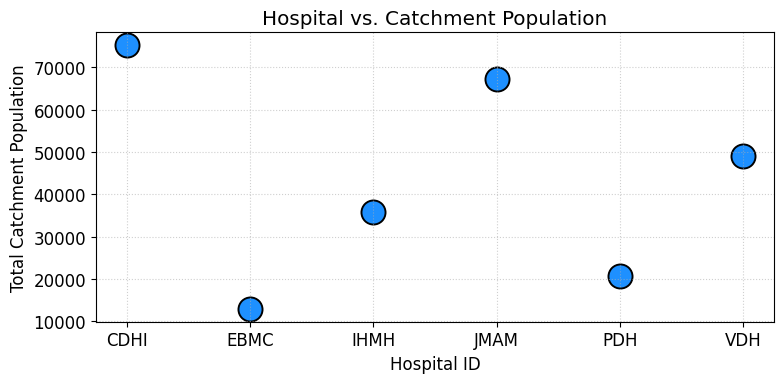

In [5]:
df = pd.read_csv('Downloads/catchment.csv')

df['population'] = pd.to_numeric(df['population'].astype(str).str.replace(',', ''), errors='coerce')

hospital_data = df.groupby('nearest_hospital')['population'].sum().reset_index()
hospital_data.columns = ['hospital', 'catchment_population']

target_hospitals = ['VDH', 'JMAM', 'CDHI', 'IHMH', 'PDH', 'EBMC']
hospital_data = hospital_data[hospital_data['hospital'].isin(target_hospitals)]

plt.figure(figsize=(8, 4))
sns.scatterplot(data=hospital_data, x='hospital', y='catchment_population', s=300, color='dodgerblue', edgecolor='black')

plt.title('Hospital vs. Catchment Population')
plt.xlabel('Hospital ID')
plt.ylabel('Total Catchment Population')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

<h2><b>MATHEMATICAL COMPONENTS</b></h2>
<p
This framework quantifies healthcare accessibility by combining hospital supply (beds), population demand, and geographic access (travel time). The goal is to measure system pressure and identify areas where healthcare capacity is insufficient relative to need.
</p>

<hr>

<table style="width:100%; text-align:left; border-collapse:collapse;">
  <tr>
    <th style="text-align:left; border-bottom:1px solid #ccc;">Metric</th>
    <th style="text-align:left; border-bottom:1px solid #ccc;">Formula</th>
    <th style="text-align:left; border-bottom:1px solid #ccc;">Meaning</th>
  </tr>

  <tr>
    <td>Beds per 1,000</td>
    <td>(beds × 1000) / population</td>
    <td>Measures hospital supply relative to population size</td>
  </tr>

  <tr>
    <td>Required beds</td>
    <td>ceil(population / 1000)</td>
    <td>Approximates minimum healthcare capacity needed</td>
  </tr>

  <tr>
    <td>Bed gap</td>
    <td>effective beds - required beds</td>
    <td>Indicates surplus or shortage of hospital capacity</td>
  </tr>

  <tr>
    <td>Catchment population</td>
    <td>sum(population)</td>
    <td>Total population dependent on a hospital system</td>
  </tr>

  <tr>
    <td>Travel burden (max)</td>
    <td>max(travel_time)</td>
    <td>Represents worst-case access delay within coverage area</td>
  </tr>

  <tr>
    <td>Travel burden (avg)</td>
    <td>avg(travel_time)</td>
    <td>Represents typical access time experienced by users</td>
  </tr>

</table>

## **RISK SCORE**

Scoring was implemented across four components that affect the output score. Higher output score = Worse Access = Higher Intervention Urgency

---

| Component | Scoring Thresholds | Max Score |
| :--- | :--- | :---: |
| **Beds per 1,000** (Catchment) | $\ge 2$ → 0 \| $\ge 1$ → 1 \| $\ge 0.5$ → 2 \| Below → 3 | **3** |
| **Travel Time** (Nearest Hospital) | $\le 15$ min → 0 \| $\le 30$ min → 1 \| $\le 60$ min → 2 \| Above → 3 | **3** |
| **Hospital Level** | Level 2+ → 0 \| Level 1 → 2 | **2** |
| **Crude Death Rate** | $\le 7$ → 0 \| $\le 12$ → 1 \| $\le 18$ → 2 \| Above → 3 \| Unknown → 1 | **3** |
| **Total Potential Risk** | | **11** |

## **CORRELATION MATRIX**
---

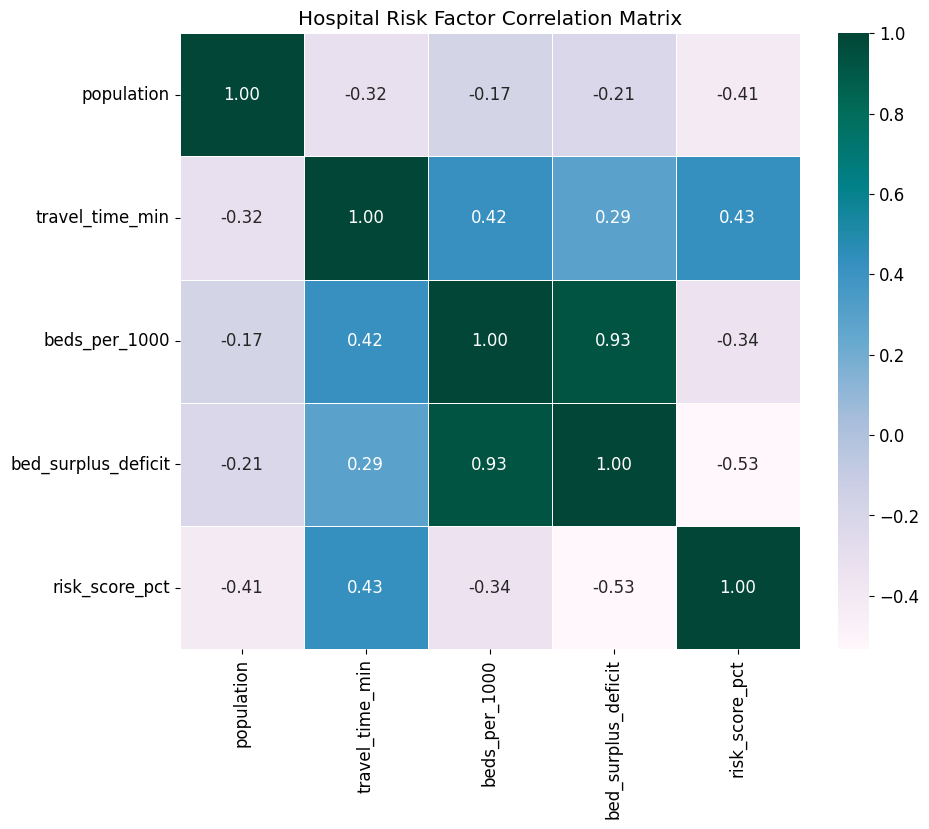

In [6]:
df = pd.read_csv('Downloads/conclusion_1.csv')

metrics = ['population', 'travel_time_min', 'beds_per_1000', 'bed_surplus_deficit', 'risk_score_pct']
numeric_df = df[metrics].apply(pd.to_numeric, errors='coerce')
corr = numeric_df.dropna().corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='PuBuGn', fmt='.2f', linewidths=0.5)
plt.title('Hospital Risk Factor Correlation Matrix')
plt.show()

* Correlation analysis shows a near-zero relationship **(-0.17)** between population and beds_per_1000, which indicates the scarcity of proper resource allocation.
* The heatmap also shows a proportional increase between travel_time_min and risk_score_pct **(0.43)**.
* More beds = safer, the heatmap reflects this inverse relationship between bed_surplus_deficit and risk_score_pct **(-0.53)**

---

## **LAND PLANS**

Probable actions to take in the future years as hospital saturation increases for each municipality and hospitals.

---


In [7]:
df = pd.read_csv('Downloads/investment_123.csv')
df.columns = df.columns.str.strip().str.lower()

def color_interventions(val):
    color_map = {
        'GREENFIELD': 'background-color: #d1e7dd; color: #0f5132; font-weight: bold',
        'EXPANSION': 'background-color: #fff3cd; color: #664d03; font-weight: bold',
        'UPGRADE': 'background-color: #cfe2ff; color: #084298; font-weight: bold',
        'PRIVATE ENTRY': 'background-color: #f8d7da; color: #842029; font-weight: bold',
        'MONITOR': 'background-color: #e2e3e5; color: #41464b; font-weight: bold',
        'TRANSPORT': 'background-color: #fdfdfe; color: #6c757d; font-weight: bold'
    }
    return color_map.get(val, '')

styled_df = (
    df.style
    .set_properties(**{
        'text-align': 'left',
        'padding': '12px 15px',
        'border-bottom': '1px solid #ececec',
        'font-family': 'Segoe UI, system-ui, sans-serif'
    })
    .format({'priority_rank': '{:.0f}'})
    .background_gradient(subset=['priority_rank'], cmap='Reds_r', low=0.2, high=0.1)
    .map(color_interventions, subset=['intervention_type']) 
    .hide(axis="index")
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#1a1a1a'),
            ('color', '#ffffff'),
            ('font-weight', '600'),
            ('text-transform', 'uppercase'),
            ('font-size', '11px'),
            ('letter-spacing', '0.05em'),
            ('padding', '15px')
        ]},
        {'selector': 'tr:hover', 'props': [('background-color', '#fafafa')]}
    ])
)

styled_df

municipality,intervention_type,priority_rank,land_play
Gigmoto,GREENFIELD,1,Buy land in Gigmoto — new facility will be built here
Caramoran,EXPANSION,2,Buy land in San Andres near JMAM — hospital grows outward
Panganiban,UPGRADE,3,Buy land in Viga near VDH — upgrade attracts clinics and pharmacy
Virac,PRIVATE ENTRY,4,Buy commercial lot in Virac — population can support a private clinic
San Miguel,PRIVATE ENTRY,5,Buy commercial lot in San Miguel — population can support a private clinic
Viga,UPGRADE,6,Buy land in Viga near VDH — upgrade attracts clinics and pharmacy
Bato,PRIVATE ENTRY,7,Buy commercial lot in Bato — population can support a private clinic
Bagamanoc,UPGRADE,8,Buy land in Viga near VDH — upgrade attracts clinics and pharmacy
San Andres,EXPANSION,9,Buy land in San Andres near JMAM — hospital grows outward
Pandan,MONITOR,10,Watch and wait


## **KEY FINDINGS**

___

### **1. Critical Capacity Gaps (Level 1 Hospitals)**
* **Juan M. Alberto Memorial** (San Andres) Serves the largest catchment of any Level 1 hospital in the province, covering **67,281 people** across Caramoran and San Andres with only **25 beds**.
* **Viga District Hospital** Supports four municipalities (Bagamanoc, Panganiban, Gigmoto, and Viga) with a total catchment of **49,062** using only **25 beds**.

### **2. Geographical Access & Regulatory Barriers**
* Some municipalities are too far from the nearest Hospital. Gigmoto, for example, is currently **78 minutes away** from the nearest hospital. This travel time represents a significant barrier to emergency and basic healthcare services.

### **3. Clinical Capability Mismatch**
* According to 2025 PSA statistics, **140 deaths** in Catanduanes were cardiovascular-related.
* Proper treatment for these cases requires, at minimum, a **Level 2 facility**.
* Multiple municipalities are served exclusively by **Level 1 hospitals** that are medically incapable of treating these high-priority cardiovascular cases.